In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
np.random.seed(42)
n_rows = 500

In [3]:
raw_data = {
    'Employee_ID': [f"EMP_{100 + i}" for i in range(n_rows)],
    'Age': np.random.choice([25, 30, 35, 40, np.nan, 45, 50], size=n_rows, p=[0.2, 0.2, 0.2, 0.2, 0.1, 0.05, 0.05]), # Has NaNs
    'Salary_USD': np.random.choice(['$45,000', '$60,000', '$85,000', 'missing', '$120,000', '$70,000'], size=n_rows), # Mixed types / symbols
    'Performance_Score': np.random.choice([1, 2, 3, 4, 5], size=n_rows, p=[0.1, 0.2, 0.4, 0.2, 0.1]),
    'Remote_Flag': np.random.choice(['Yes', 'yes', 'NO', 'no', '  Yes  '], size=n_rows) # Inconsistent string formatting & whitespaces
}

In [4]:
df_raw = pd.DataFrame(raw_data)

In [6]:
df_raw = pd.concat([df_raw, df_raw.iloc[10:15]], ignore_index=True)

In [7]:
df_raw.head(12)

,Employee_ID,Age,Salary_USD,Performance_Score,Remote_Flag
0,EMP_100,30.0,"$70,000",3,Yes
1,EMP_101,50.0,"$45,000",5,NO
2,EMP_102,40.0,"$45,000",3,no
3,EMP_103,35.0,"$45,000",1,yes
4,EMP_104,25.0,"$120,000",5,yes
5,EMP_105,25.0,missing,2,NO
6,EMP_106,25.0,"$120,000",3,Yes
7,EMP_107,NaN,missing,2,Yes
8,EMP_108,40.0,"$120,000",1,NO
9,EMP_109,40.0,"$120,000",3,NO


# Raw Data Audit (Finding the Issues)

In [9]:
print(df_raw.isnull().sum())
print(f"Total duplicates: {df_raw.duplicated().sum()}")
print(df_raw['Salary_USD'].unique()[:5])
print(df_raw['Remote_Flag'].unique())

Employee_ID           0
Age                  53
Salary_USD            0
Performance_Score     0
Remote_Flag           0
dtype: int64
Total duplicates: 10
['$70,000' '$45,000' '$120,000' 'missing' '$85,000']
['  Yes  ' 'NO' 'no' 'yes' 'Yes']


#  Data Cleaning Pipeline

In [10]:
df_clean = df_raw.copy()

df_clean = df_clean.drop_duplicates()

df_clean['Salary_USD'] = df_clean['Salary_USD'].replace('missing', np.nan)
df_clean['Salary_USD'] = df_clean['Salary_USD'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df_clean['Salary_USD'] = df_clean['Salary_USD'].astype(float)

df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].mean())
df_clean['Salary_USD'] = df_clean['Salary_USD'].fillna(df_clean['Salary_USD'].median())

df_clean['Remote_Flag'] = df_clean['Remote_Flag'].str.strip().str.lower()
df_clean['Remote_Flag'] = df_clean['Remote_Flag'].map({'yes': 1, 'no': 0})

print("Cleaning complete! Post-cleaning missing counts:")
print(df_clean.isnull().sum())

Cleaning complete! Post-cleaning missing counts:
Employee_ID          0
Age                  0
Salary_USD           0
Performance_Score    0
Remote_Flag          0
dtype: int64


#  Visual Insights & Correlation Heatmap

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19832\2692934566.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Performance_Score', y='Salary_USD', data=df_clean, ax=ax[1], palette='Set2')


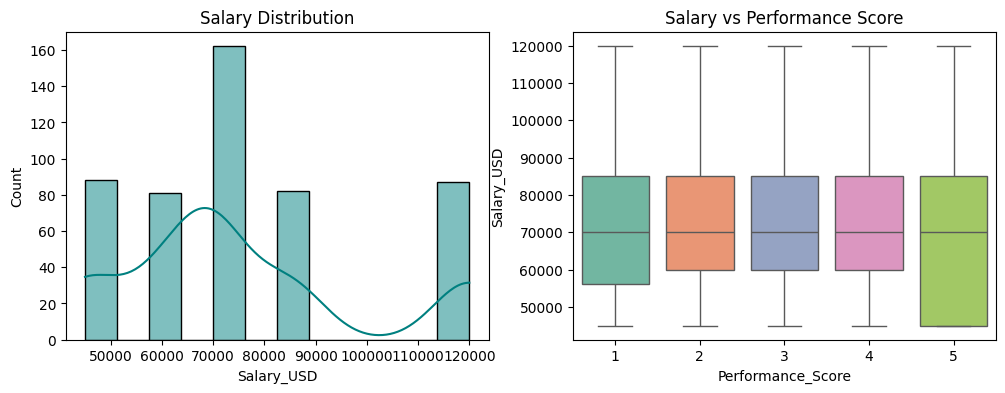

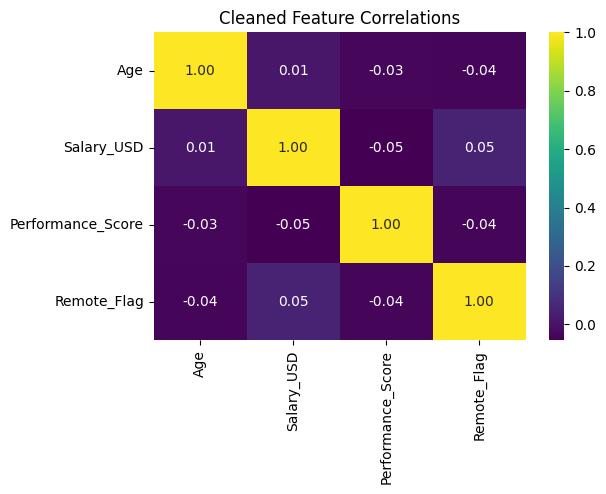

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_clean['Salary_USD'], kde=True, ax=ax[0], color='teal')
ax[0].set_title('Salary Distribution')

sns.boxplot(x='Performance_Score', y='Salary_USD', data=df_clean, ax=ax[1], palette='Set2')
ax[1].set_title('Salary vs Performance Score')
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(df_clean[['Age', 'Salary_USD', 'Performance_Score', 'Remote_Flag']].corr(), 
            annot=True, cmap='viridis', fmt=".2f")
plt.title("Cleaned Feature Correlations")
plt.show()

#  Model Training & Testing Preparation

In [18]:
df_clean['High_Performer'] = (df_clean['Performance_Score'] >= 4).astype(int)

In [19]:
X = df_clean[['Age', 'Salary_USD', 'Remote_Flag']]
y = df_clean['High_Performer']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
y_pred = clf.predict(X_test)
print("Classification Accuracy:", accuracy_score(y_test, y_pred))

Classification Accuracy: 0.66


#  Evaluation Matrix Heatmap

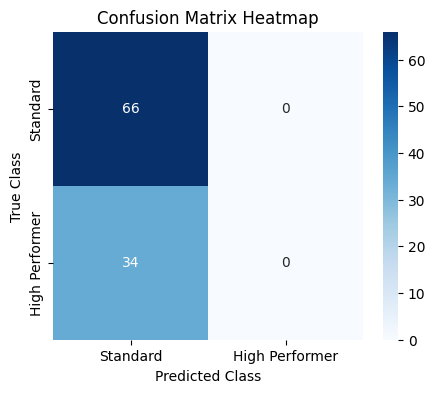

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Standard', 'High Performer'],
            yticklabels=['Standard', 'High Performer'])
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix Heatmap')
plt.show()

#  Real-Time New Input Prediction

In [31]:
new_employee_raw = np.array([[38, 85000, 1]])

new_employee_df = pd.DataFrame(new_employee_raw, columns=X.columns)

prediction = clf.predict(new_employee_df)[0]
probability = clf.predict_proba(new_employee_df)[0][1]

print(f"Prediction for new sample: Class {prediction}")
print(f"Likelihood of being classified as a High Performer: {probability * 100:.2f}%")

Prediction for new sample: Class 0
Likelihood of being classified as a High Performer: 34.46%


#  Saving Trained Pipeline to File using Joblib

In [33]:
import joblib

joblib.dump(pipeline, 'production_pipeline.joblib')

['production_pipeline.joblib']

#  Loading Saved Pipeline File for Instant Future Use

In [34]:
loaded_pipeline = joblib.load('production_pipeline.joblib')

Pipeline loaded successfully from file storage.
